# 和歌山県内6市の基礎分析・クラスタリング

本Notebookでは、**和歌山県内でデータが取得できる6市（和歌山市、岩出市、橋本市、海南市、田辺市、紀の川市）を対象に、基礎分析およびクラスタリングを行う。**

まず、各市の**主観的ウェルビーイング（幸福度）と24カテゴリの主観評価**を整理し、市ごとの特徴や強み・弱みを把握する。

その後、24カテゴリの主観評価を用いて**クラスタリングを探索的に実施し、6市の類型化が可能かを検討する。**

## クラスタリング結果

クラスタ数を $k=2,3,4$ としてクラスタリングを行い、シルエット係数を比較した。

| クラスタ数 $k$ | シルエット係数 |
| --------: | ------: |
|         2 |   0.160 |
|         3 |   0.153 |
|         4 |   0.114 |

いずれのクラスタ数でもシルエット係数は低く、**6市の24カテゴリの主観評価から明確なクラスタ構造は確認できなかった。**

したがって、本分析では、

> **6市の24カテゴリを用いたクラスタリングを探索的に実施したが、明確なクラスタ構造は確認できなかった。そのため、クラスタリングによる市の類型化・比較対象市の選定は行わない。**

とした。

以降では、クラスタリングの結果による類型化ではなく、**6市の基礎分析で得られた主観的ウェルビーイングの特徴、24カテゴリの強み・弱み、地域特性および今後のまちづくりの方向性を踏まえて分析対象市を選定する。**


In [ ]:
#pip install pandas path　scikit-learn

In [17]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
##データの読み込みと結合

In [13]:
# src フォルダから見て1つ上の層にある data フォルダを参照
DATA_DIR = Path("../data")


def load_csv_safely(file_path):
    """Shift_JIS(cp932) や UTF-8 など、適切な文字コードを試して読み込む"""
    for enc in ["cp932", "shift_jis", "utf-8-sig", "utf-8"]:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except (UnicodeDecodeError, UnicodeError):
            continue
    raise UnicodeDecodeError(
        f"全文字コードで読み込みに失敗しました: {file_path}"
    )


# 1. フォルダ内の全CSVファイルを取得
all_csvs = list(DATA_DIR.glob("*.csv")) + list(DATA_DIR.glob("*.CSV"))
print(f"📁 検出された全CSVファイル数: {len(all_csvs)} 件\n")

DATA_TYPES = ["幸福度・生活満足度", "カテゴリー別", "主観"]
dfs = {}

# 2. ファイル名キーワードで抽出して結合・確認
for dtype in DATA_TYPES:
    matched_files = [f for f in all_csvs if dtype in f.name]

    if matched_files:
        temp_dfs = []
        for f in matched_files:
            df_temp = load_csv_safely(f)
            temp_dfs.append(df_temp)

        dfs[dtype] = pd.concat(temp_dfs, ignore_index=True)

        print(
            f"=== 【{dtype}】 (対象: {len(matched_files)} ファイル) ==="
        )
        print(f"・データサイズ (行, 列): {dfs[dtype].shape}")
        display(dfs[dtype].head(5))
        print("-" * 50 + "\n")
    else:
        print(
            f"⚠️ 【{dtype}】 に一致するファイルがありませんでした。"
        )

📁 検出された全CSVファイル数: 18 件

=== 【幸福度・生活満足度】 (対象: 6 ファイル) ===
・データサイズ (行, 列): (294, 7)


,年度,調査種別,地域,データ種別,設問,回答,回答割合
0,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,幸福度・生活満足度,幸福度,10,7.6
1,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,幸福度・生活満足度,幸福度,9,7.6
2,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,幸福度・生活満足度,幸福度,8,21.9
3,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,幸福度・生活満足度,幸福度,7,21.0
4,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,幸福度・生活満足度,幸福度,6,8.6


--------------------------------------------------

=== 【カテゴリー別】 (対象: 6 ファイル) ===
・データサイズ (行, 列): (144, 9)


,年度,調査種別,地域,データ種別,因子群,カテゴリ・評価指標,主観データ実数,主観データ偏差値,客観データ偏差値
0,2026年度版(令和8年度版),全国調査,和歌山県 紀の川市,カテゴリー別,生活環境,医療・福祉,3.1,41.0,49.2
1,2026年度版(令和8年度版),全国調査,和歌山県 紀の川市,カテゴリー別,生活環境,買物・飲食,2.9,28.1,39.4
2,2026年度版(令和8年度版),全国調査,和歌山県 紀の川市,カテゴリー別,生活環境,住宅環境,3.6,62.6,63.6
3,2026年度版(令和8年度版),全国調査,和歌山県 紀の川市,カテゴリー別,生活環境,移動・交通,2.2,33.2,42.3
4,2026年度版(令和8年度版),全国調査,和歌山県 紀の川市,カテゴリー別,生活環境,遊び・娯楽,2.2,30.5,47.6


--------------------------------------------------

=== 【主観】 (対象: 6 ファイル) ===
・データサイズ (行, 列): (420, 8)


,年度,調査種別,地域,データ種別,因子群,カテゴリ・評価指標,実数,偏差値
0,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,主観データ,生活環境,医療機関が充実,3.0,29.9
1,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,主観データ,生活環境,介護福祉サービス良,3.0,32.8
2,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,主観データ,生活環境,買い物に不便がない,3.2,32.0
3,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,主観データ,生活環境,飲食を楽しめる,3.0,39.9
4,2026年度版(令和8年度版),全国調査,和歌山県 橋本市,主観データ,生活環境,自宅に心地のいい居場所,3.7,52.4


--------------------------------------------------



In [8]:
# 1. 含まれている「地域（市）」の確認
print("=== 📍 含まれる地域の一覧 ===")
for dtype, df in dfs.items():
    cities = df["地域"].unique()
    print(f"【{dtype}】({len(cities)}地域): {list(cities)}")

print("\n" + "=" * 50 + "\n")

# 2. 欠損値とデータ型の確認
print("=== 🔍 欠損値とデータ状態のチェック ===")
for dtype, df in dfs.items():
    null_count = df.isnull().sum().sum()
    print(
        f"【{dtype}】 Total欠損数: {null_count} / 行数: {len(df)} / 列数: {len(df.columns)}"
    )

print("\n" + "=" * 50 + "\n")

# 3. 各数値カラムの基本統計量（平均値・最小・最大など）
print("=== 📊 主観データの偏差値分布（参考） ===")
display(dfs["主観"][["実数", "偏差値"]].describe())

=== 📍 含まれる地域の一覧 ===
【幸福度・生活満足度】(6地域): ['和歌山県 橋本市', '和歌山県 紀の川市', '和歌山県 岩出市', '和歌山県 海南市', '和歌山県 和歌山市', '和歌山県 田辺市']
【カテゴリー別】(6地域): ['和歌山県 紀の川市', '和歌山県 和歌山市', '和歌山県 岩出市', '和歌山県 海南市', '和歌山県 橋本市', '和歌山県 田辺市']
【主観】(6地域): ['和歌山県 橋本市', '和歌山県 海南市', '和歌山県 岩出市', '和歌山県 紀の川市', '和歌山県 田辺市', '和歌山県 和歌山市']


=== 🔍 欠損値とデータ状態のチェック ===
【幸福度・生活満足度】 Total欠損数: 0 / 行数: 294 / 列数: 7
【カテゴリー別】 Total欠損数: 0 / 行数: 144 / 列数: 9
【主観】 Total欠損数: 0 / 行数: 420 / 列数: 8


=== 📊 主観データの偏差値分布（参考） ===


,実数,偏差値
count,420.000000,420.000000
mean,2.966190,43.924524
std,0.356394,9.331978
min,2.100000,20.400000
25%,2.700000,37.075000
50%,3.000000,43.000000
75%,3.200000,49.400000
max,3.900000,72.300000


In [11]:
# 幸福度の平均スコア（加重平均）を市ごとに算出
df_hap = dfs["幸福度・生活満足度"]
df_hap_score = df_hap[df_hap["設問"] == "幸福度"].copy()

# 加重計算（回答値 × 回答割合 / 100）
df_hap_score["スコア貢献度"] = (
    df_hap_score["回答"] * df_hap_score["回答割合"] / 100
)

# 市ごとに合計して平均スコアを算出
mean_happiness = (
    df_hap_score.groupby("地域")["スコア貢献度"]
    .sum()
    .reset_index()
    .rename(columns={"スコア貢献度": "平均幸福度スコア"})
)
display(mean_happiness.sort_values(by="平均幸福度スコア", ascending=False))

,地域,平均幸福度スコア
5,和歌山県 紀の川市,6.924
3,和歌山県 海南市,6.489
2,和歌山県 橋本市,6.488
0,和歌山県 和歌山市,6.381
1,和歌山県 岩出市,6.344
4,和歌山県 田辺市,6.144


In [15]:
# ============================================
# 6市 × 24分野の主観スコア比較
# ============================================

df_cat = dfs["カテゴリー別"].copy()

# 和歌山県の市名だけを抽出
df_cat["市"] = df_cat["地域"].str.replace("和歌山県 ", "", regex=False)

# 必要な列だけ確認
print("対象市:")
print(df_cat["市"].unique())

print("\n市ごとのデータ数:")
print(df_cat.groupby("市").size())

# --------------------------------------------
# 1. 市 × 24分野の主観偏差値
# --------------------------------------------

city_subjective = df_cat.pivot_table(
    index="市",
    columns="カテゴリ・評価指標",
    values="主観データ偏差値"
)

display(city_subjective)

# --------------------------------------------
# 2. 市 × 24分野の全国平均との差
# --------------------------------------------
# 全国平均50を基準にする
city_gap = city_subjective - 50

print("=== 全国平均（50）との差 ===")
display(city_gap)

# --------------------------------------------
# 3. 各市の「高い分野・低い分野」を確認
# --------------------------------------------

for city in city_gap.index:
    print(f"\n===== {city} =====")

    print("\n▼ 高い分野")
    print(
        city_gap.loc[city]
        .sort_values(ascending=False)
        .head(5)
    )

    print("\n▼ 低い分野")
    print(
        city_gap.loc[city]
        .sort_values()
        .head(5)
    )

対象市:
<StringArray>
['紀の川市', '和歌山市', '岩出市', '海南市', '橋本市', '田辺市']
Length: 6, dtype: str

市ごとのデータ数:
市
和歌山市    24
岩出市     24
橋本市     24
海南市     24
田辺市     24
紀の川市    24
dtype: int64


カテゴリ・評価指標,デジタル生活,事故・犯罪,事業創造,住宅環境,健康状態,公共空間,初等・中等教育,医療・福祉,地域とのつながり,地域行政,...,環境共生,移動・交通,自己効力感,自然の恵み,自然景観,自然災害,買物・飲食,遊び・娯楽,都市景観,雇用・所得
市,,,,,,,,,,,,,,,,,,,,,
和歌山市,37.1,43.4,36.2,53.5,46.0,46.2,45.2,51.2,44.7,41.4,...,35.6,43.0,48.8,49.4,51.8,38.8,48.9,44.0,46.4,38.5
岩出市,40.9,43.0,43.6,49.7,44.8,37.3,37.8,46.0,46.2,39.0,...,44.0,36.8,44.0,54.7,44.9,41.6,58.9,43.2,45.7,42.0
橋本市,44.9,44.8,35.4,59.3,43.0,44.0,23.3,31.4,51.1,40.4,...,47.8,39.8,42.3,63.7,59.3,51.3,35.9,34.6,42.5,30.6
海南市,36.3,34.6,31.9,53.1,60.9,34.0,30.3,35.0,57.3,41.9,...,35.0,34.6,57.9,54.3,42.7,44.5,22.0,33.4,37.3,30.0
田辺市,35.0,43.9,36.4,45.8,45.4,40.9,33.3,35.4,49.4,35.4,...,49.3,31.0,29.3,64.5,62.2,44.5,39.2,35.0,43.3,34.8
紀の川市,43.4,36.8,35.2,62.6,63.8,49.4,35.2,41.0,59.7,45.5,...,49.3,33.2,56.3,63.8,54.5,52.0,28.1,30.5,39.7,32.0


=== 全国平均（50）との差 ===


カテゴリ・評価指標,デジタル生活,事故・犯罪,事業創造,住宅環境,健康状態,公共空間,初等・中等教育,医療・福祉,地域とのつながり,地域行政,...,環境共生,移動・交通,自己効力感,自然の恵み,自然景観,自然災害,買物・飲食,遊び・娯楽,都市景観,雇用・所得
市,,,,,,,,,,,,,,,,,,,,,
和歌山市,-12.9,-6.6,-13.8,3.5,-4.0,-3.8,-4.8,1.2,-5.3,-8.6,...,-14.4,-7.0,-1.2,-0.6,1.8,-11.2,-1.1,-6.0,-3.6,-11.5
岩出市,-9.1,-7.0,-6.4,-0.3,-5.2,-12.7,-12.2,-4.0,-3.8,-11.0,...,-6.0,-13.2,-6.0,4.7,-5.1,-8.4,8.9,-6.8,-4.3,-8.0
橋本市,-5.1,-5.2,-14.6,9.3,-7.0,-6.0,-26.7,-18.6,1.1,-9.6,...,-2.2,-10.2,-7.7,13.7,9.3,1.3,-14.1,-15.4,-7.5,-19.4
海南市,-13.7,-15.4,-18.1,3.1,10.9,-16.0,-19.7,-15.0,7.3,-8.1,...,-15.0,-15.4,7.9,4.3,-7.3,-5.5,-28.0,-16.6,-12.7,-20.0
田辺市,-15.0,-6.1,-13.6,-4.2,-4.6,-9.1,-16.7,-14.6,-0.6,-14.6,...,-0.7,-19.0,-20.7,14.5,12.2,-5.5,-10.8,-15.0,-6.7,-15.2
紀の川市,-6.6,-13.2,-14.8,12.6,13.8,-0.6,-14.8,-9.0,9.7,-4.5,...,-0.7,-16.8,6.3,13.8,4.5,2.0,-21.9,-19.5,-10.3,-18.0



===== 和歌山市 =====

▼ 高い分野
カテゴリ・評価指標
住宅環境     3.5
自然景観     1.8
医療・福祉    1.2
自然の恵み   -0.6
買物・飲食   -1.1
Name: 和歌山市, dtype: float64

▼ 低い分野
カテゴリ・評価指標
環境共生       -14.4
事業創造       -13.8
デジタル生活     -12.9
教育機会の豊かさ   -11.6
雇用・所得      -11.5
Name: 和歌山市, dtype: float64

===== 岩出市 =====

▼ 高い分野
カテゴリ・評価指標
買物・飲食       8.9
自然の恵み       4.7
多様性と寛容性     1.9
住宅環境       -0.3
地域とのつながり   -3.8
Name: 岩出市, dtype: float64

▼ 低い分野
カテゴリ・評価指標
移動・交通     -13.2
公共空間      -12.7
初等・中等教育   -12.2
子育て       -11.1
地域行政      -11.0
Name: 岩出市, dtype: float64

===== 橋本市 =====

▼ 高い分野
カテゴリ・評価指標
自然の恵み       13.7
住宅環境         9.3
自然景観         9.3
自然災害         1.3
地域とのつながり     1.1
Name: 橋本市, dtype: float64

▼ 低い分野
カテゴリ・評価指標
初等・中等教育   -26.7
雇用・所得     -19.4
医療・福祉     -18.6
遊び・娯楽     -15.4
事業創造      -14.6
Name: 橋本市, dtype: float64

===== 海南市 =====

▼ 高い分野
カテゴリ・評価指標
健康状態        10.9
自己効力感        7.9
地域とのつながり     7.3
自然の恵み        4.3
住宅環境         3.1
Name: 海南市, dtype: float64

▼ 低い分野
カテゴリ・評価指標
買物・飲食      -28.0
雇用・所得      -20.0
初等・中等教育  

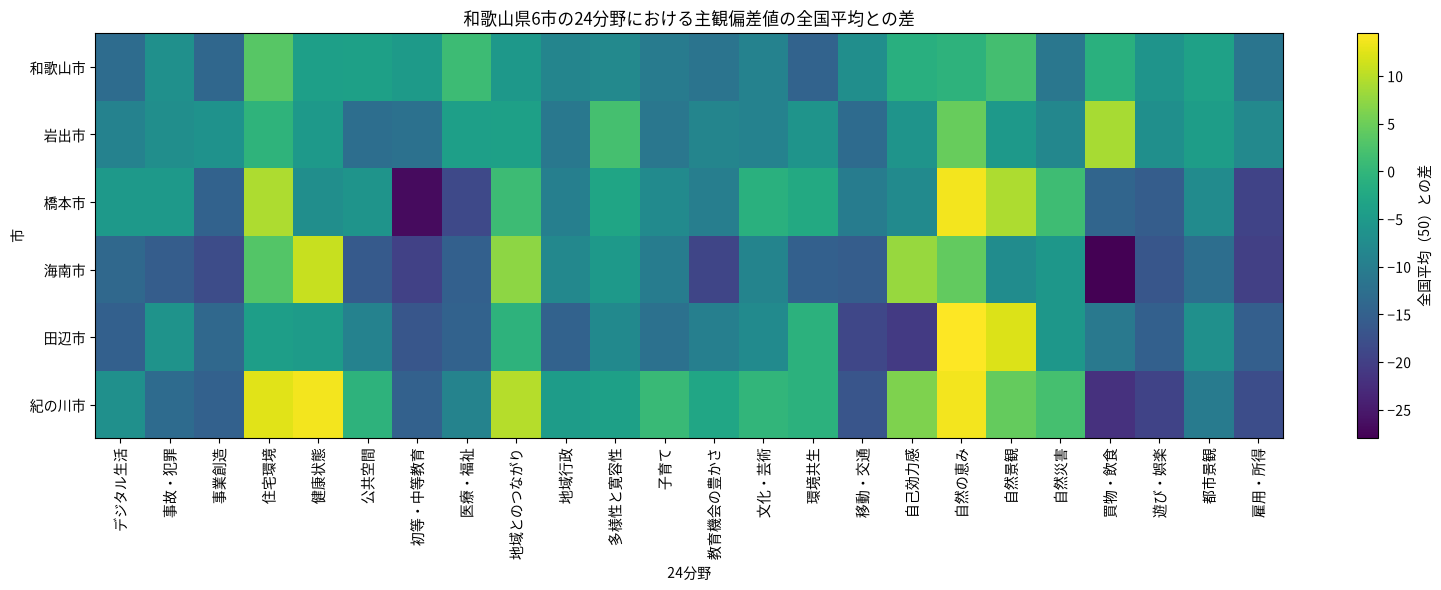

In [19]:
# 日本語フォントを指定
plt.rcParams["font.family"] = "Noto Sans CJK JP"
plt.figure(figsize=(16, 6))

plt.imshow(city_gap, aspect="auto")

plt.xticks(
    range(len(city_gap.columns)),
    city_gap.columns,
    rotation=90
)

plt.yticks(
    range(len(city_gap.index)),
    city_gap.index
)

plt.colorbar(label="全国平均（50）との差")

plt.title("和歌山県6市の24分野における主観偏差値の全国平均との差")
plt.xlabel("24分野")
plt.ylabel("市")

plt.tight_layout()
plt.show()

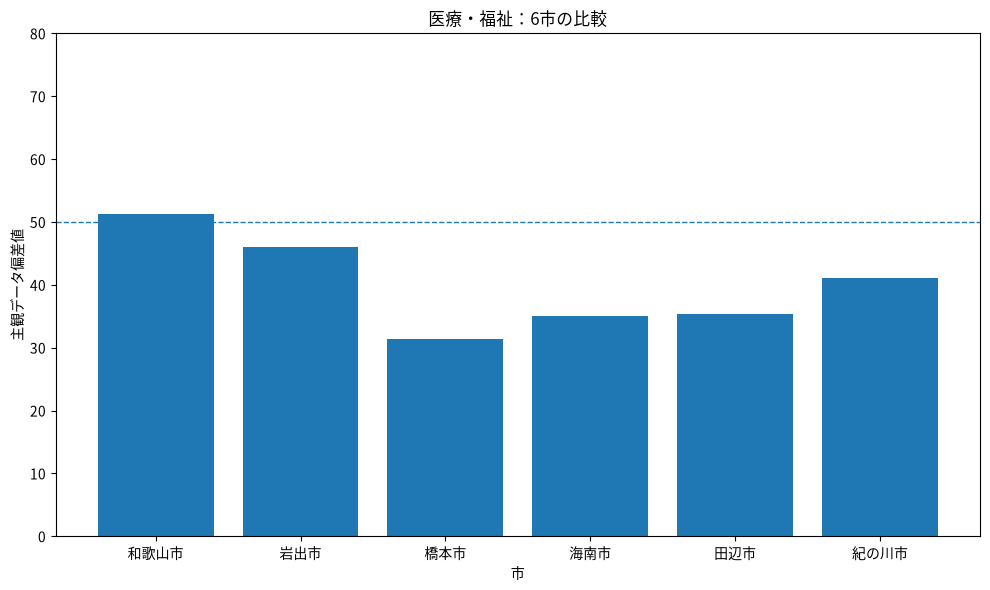

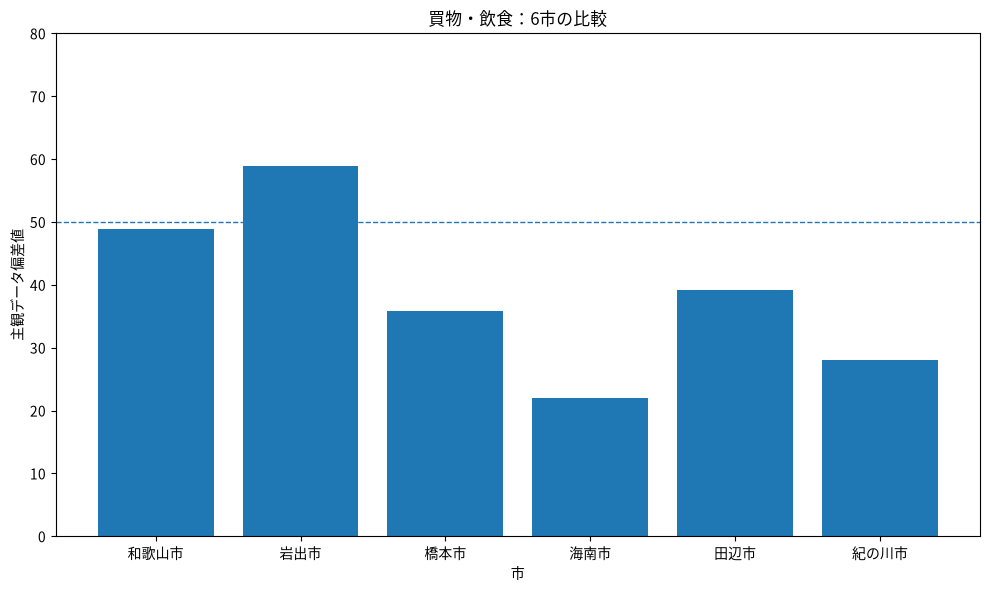

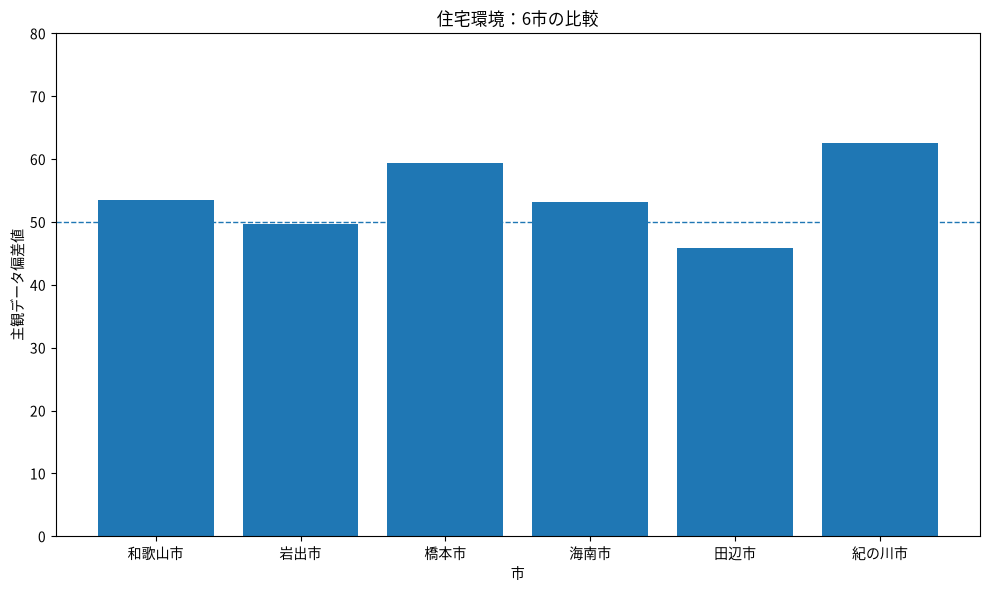

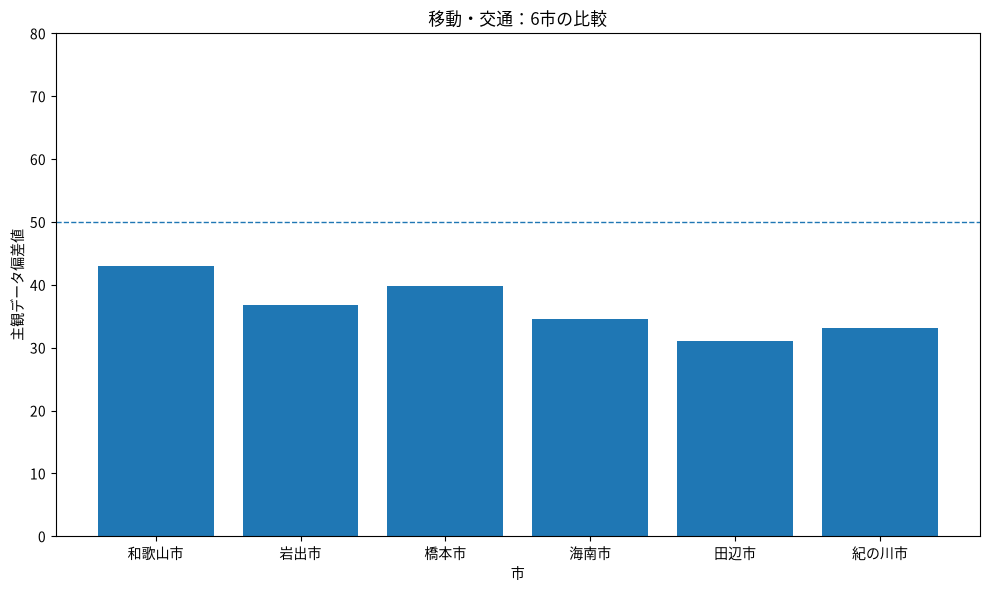

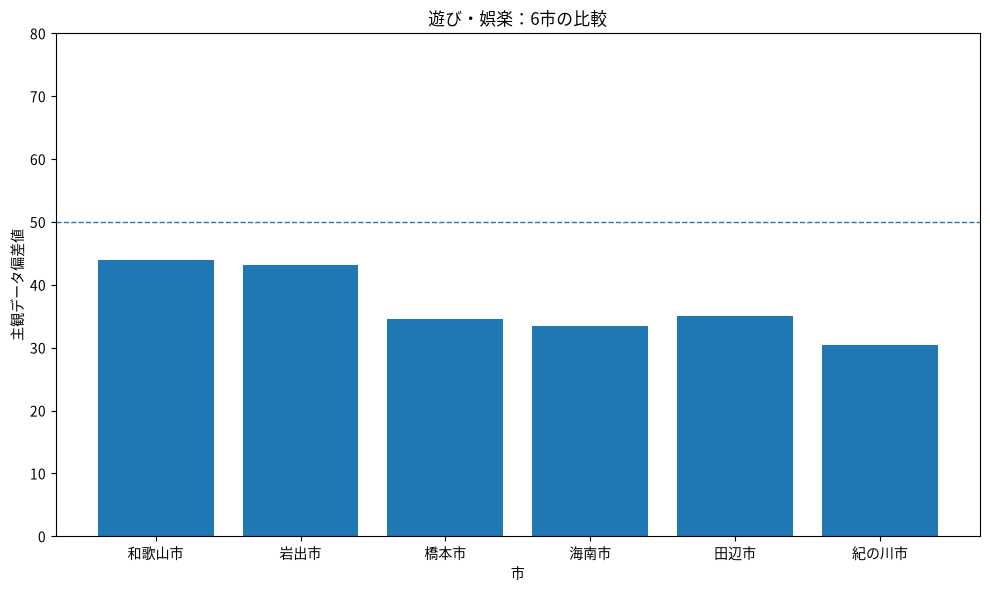

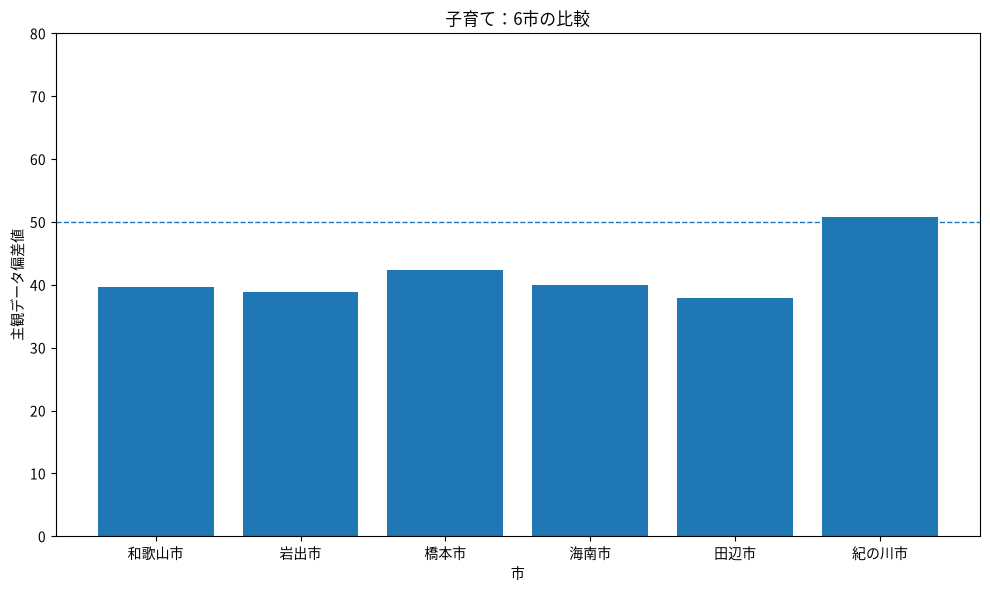

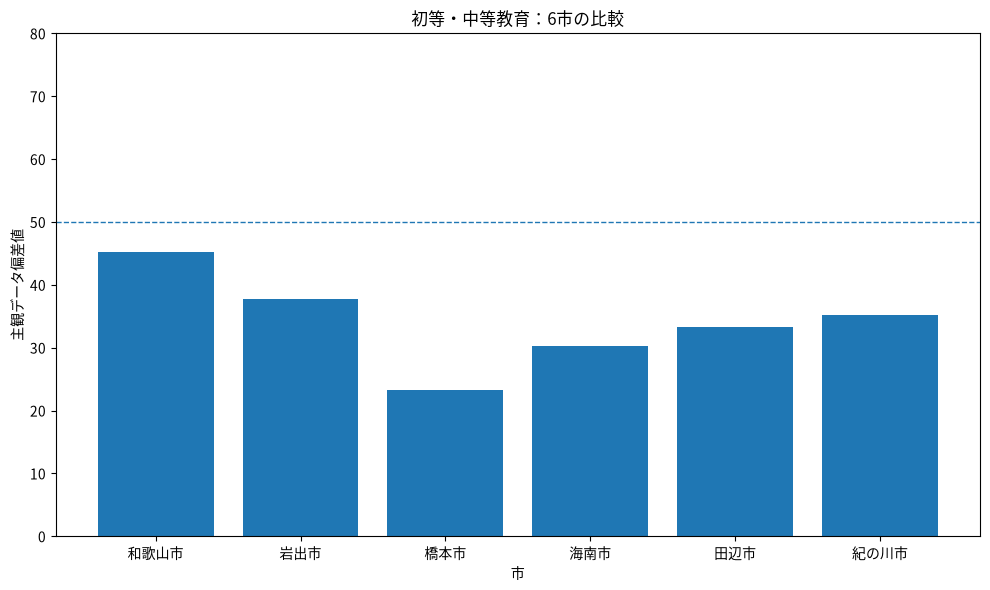

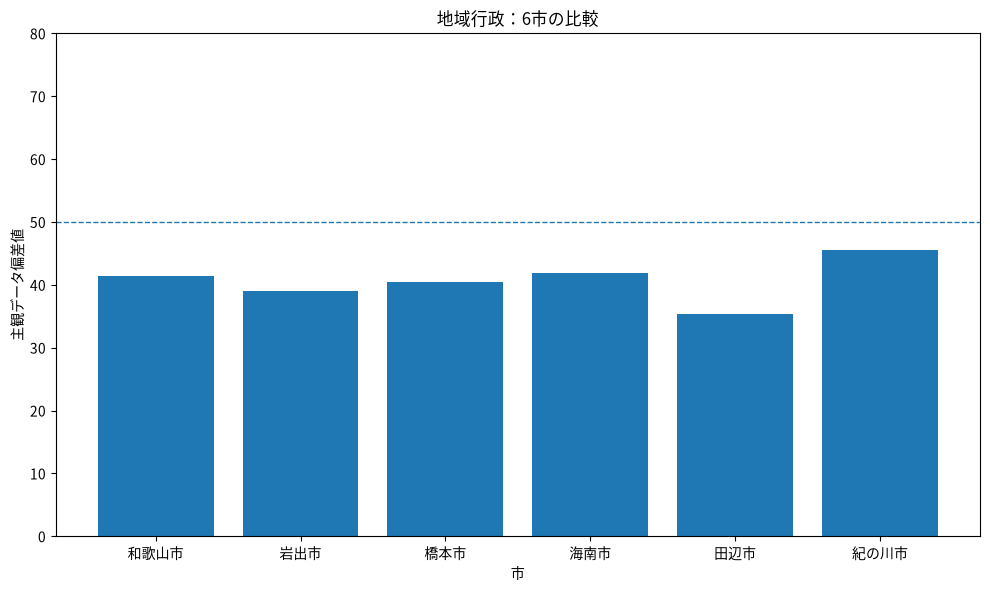

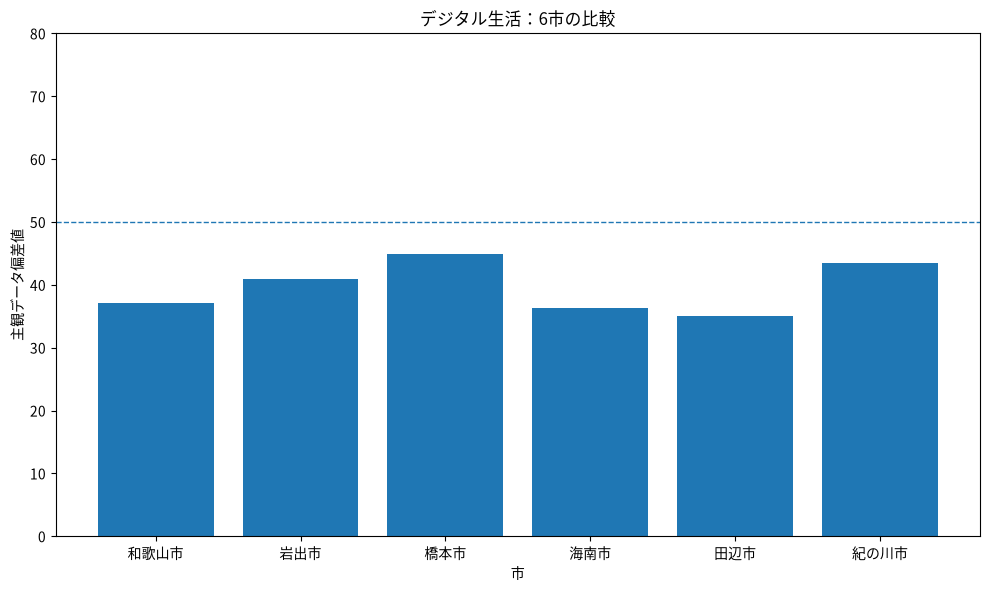

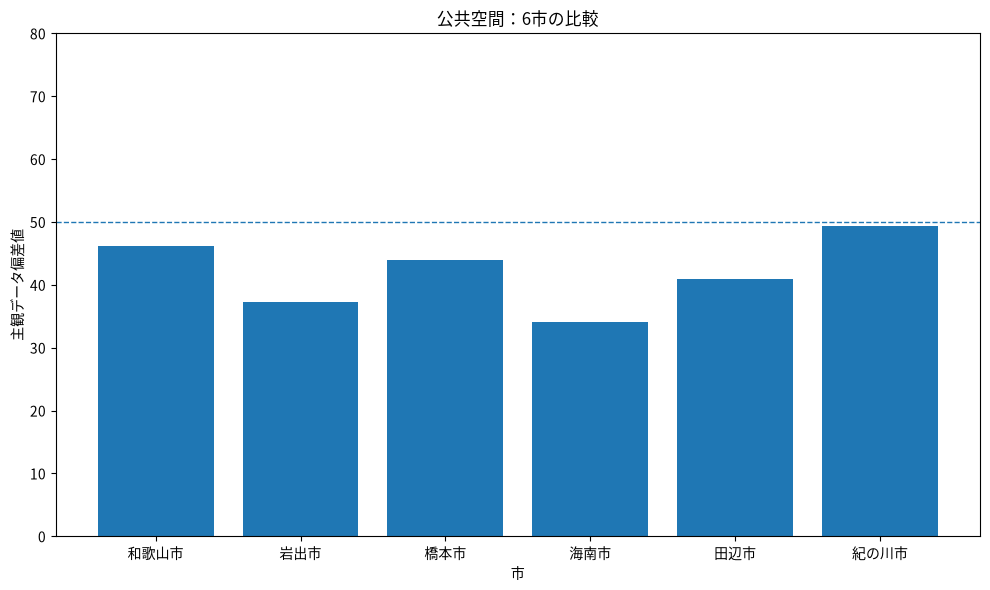

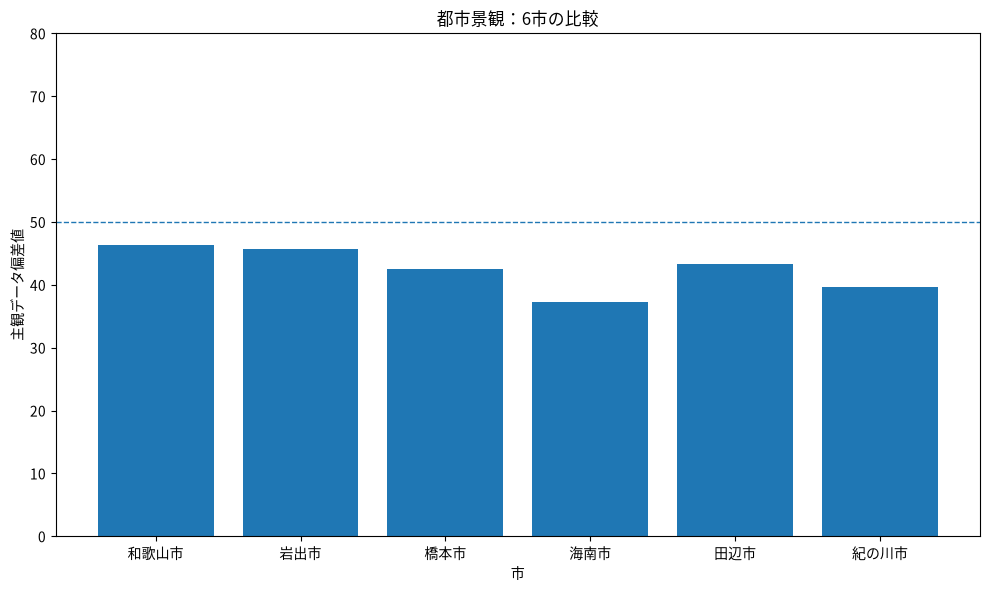

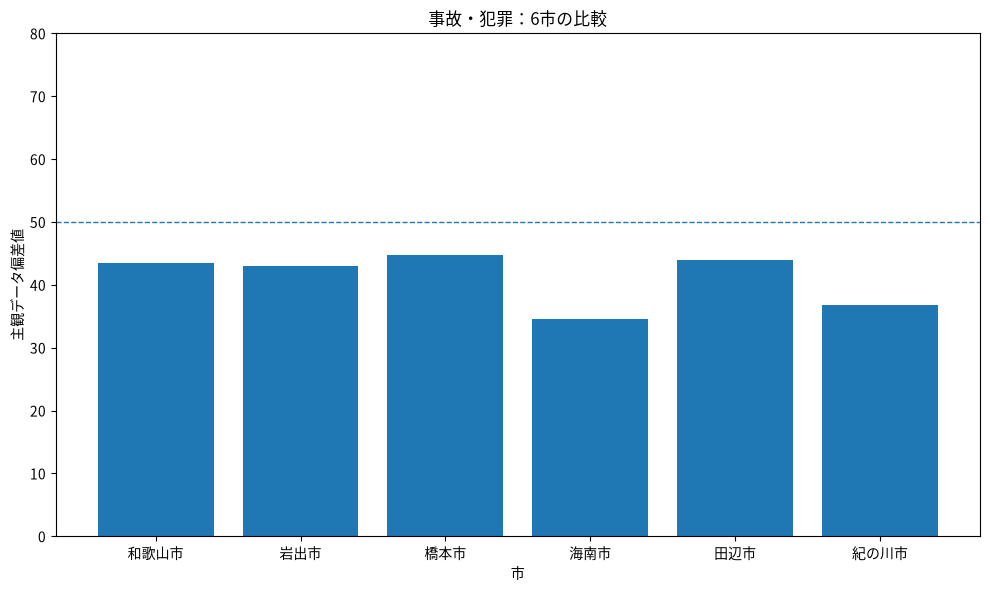

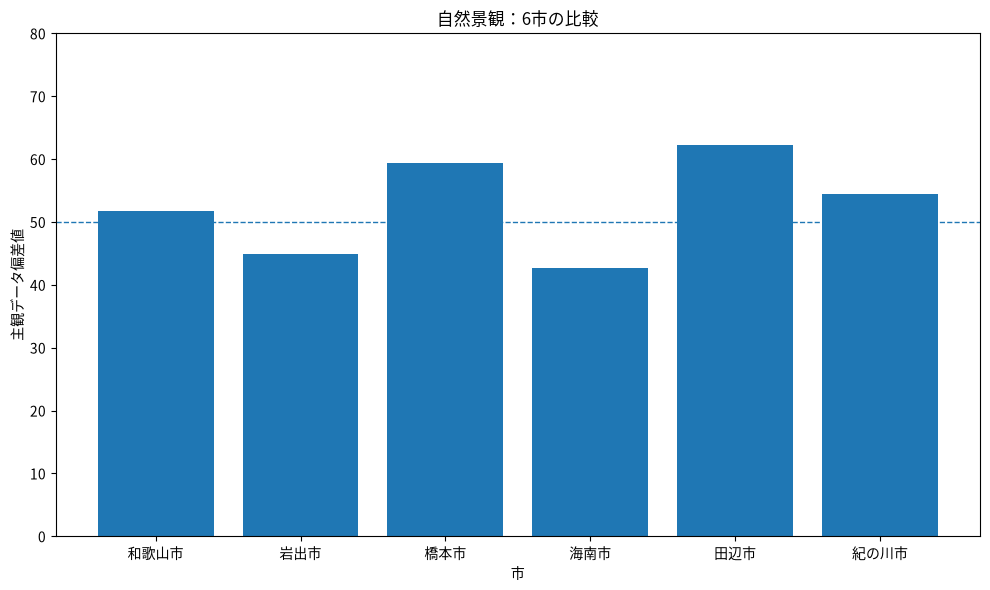

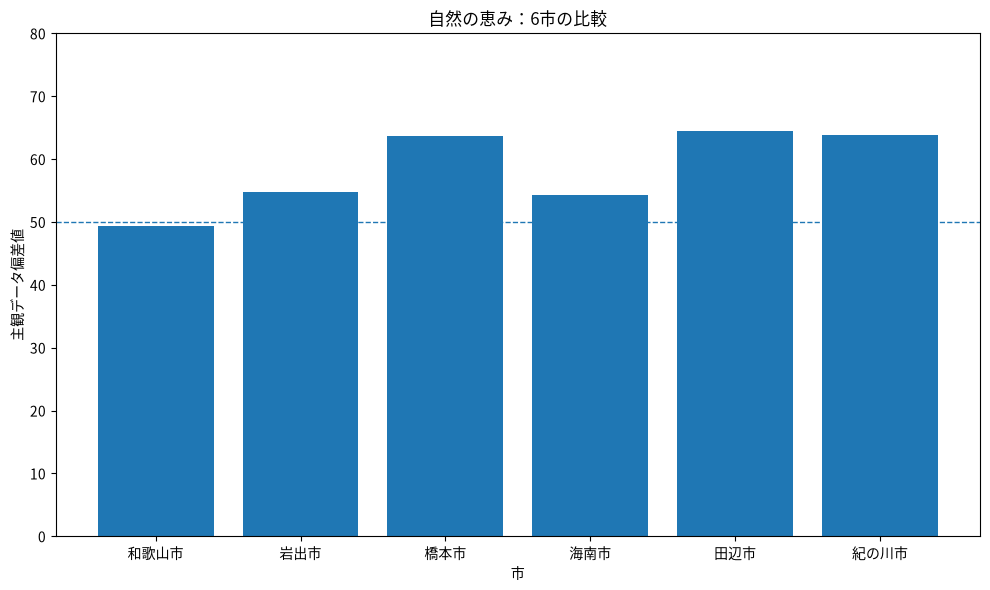

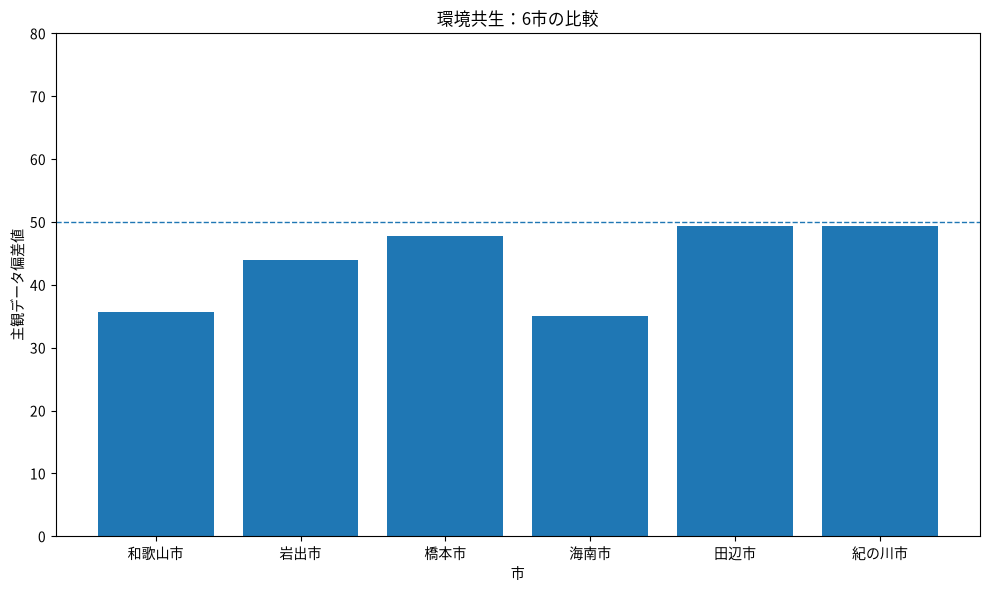

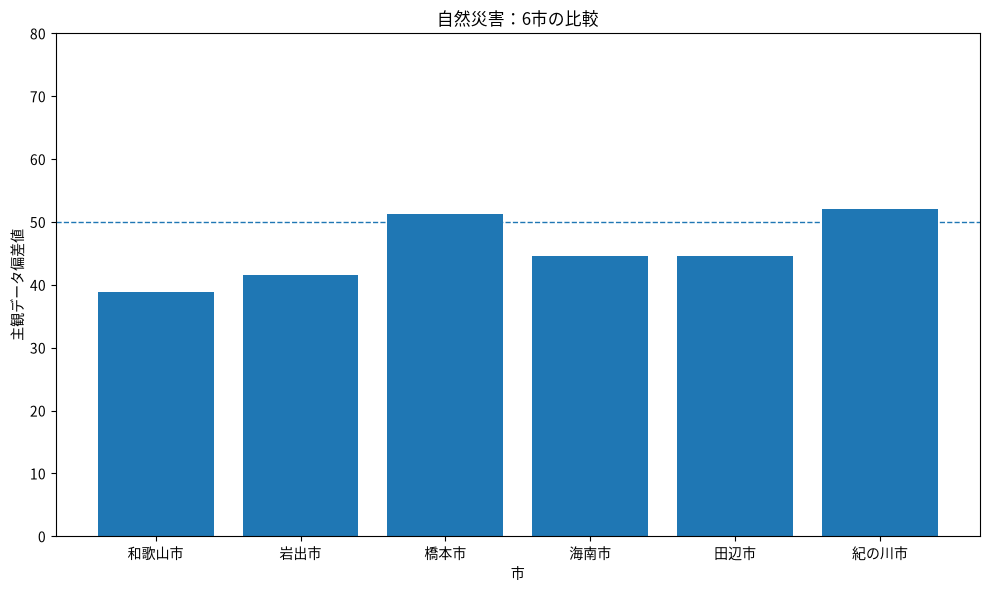

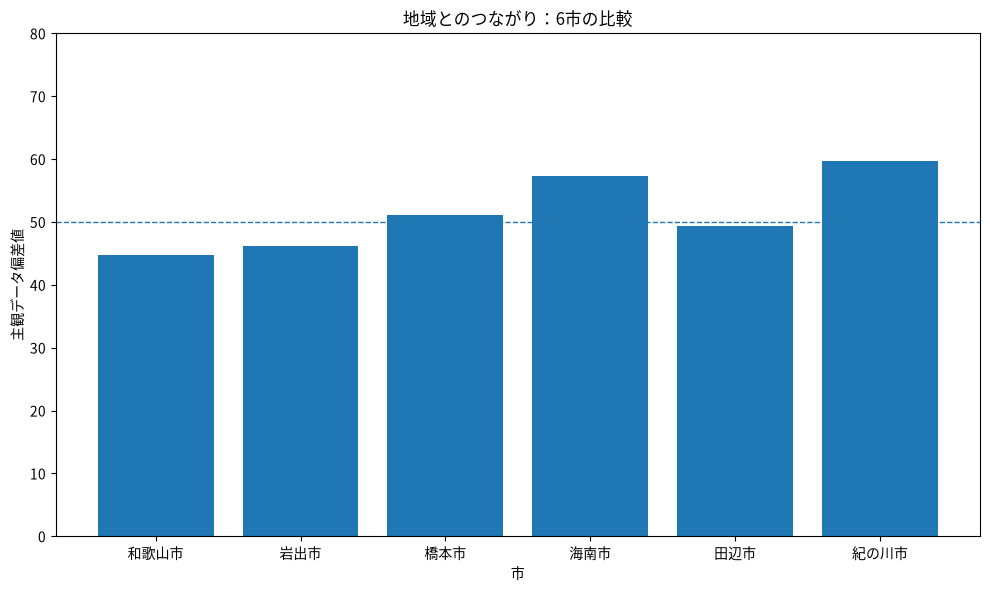

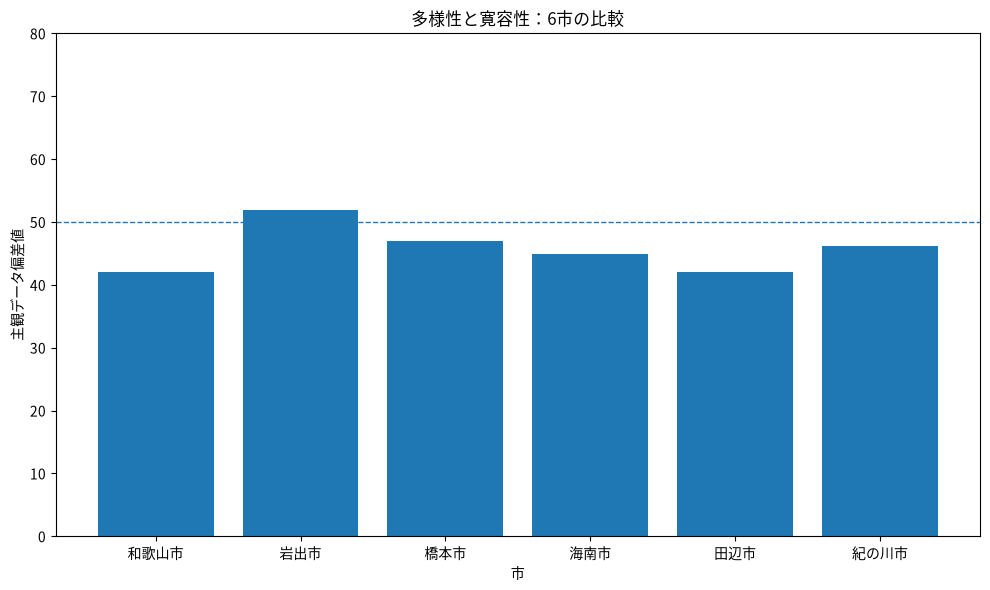

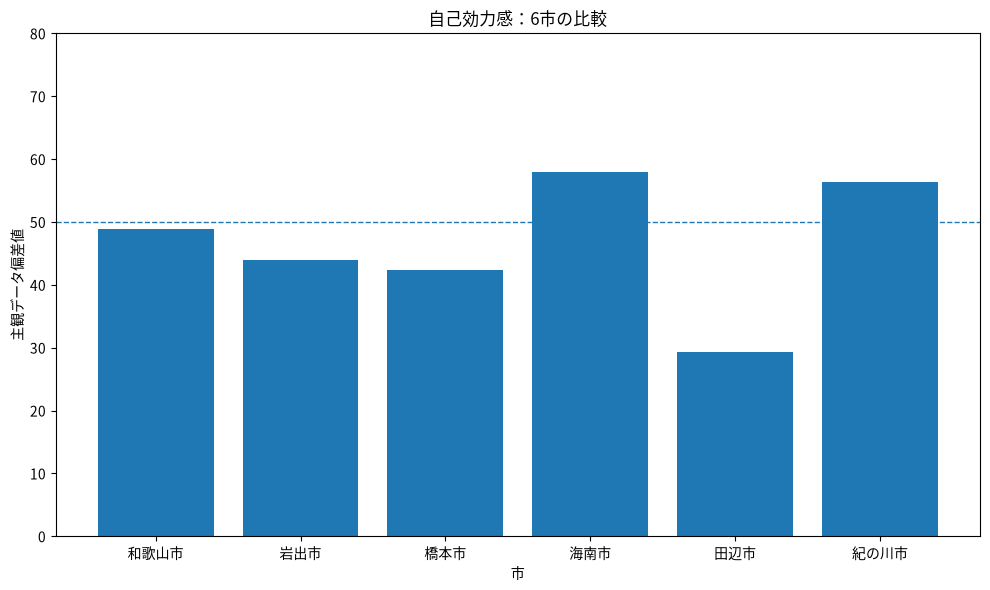

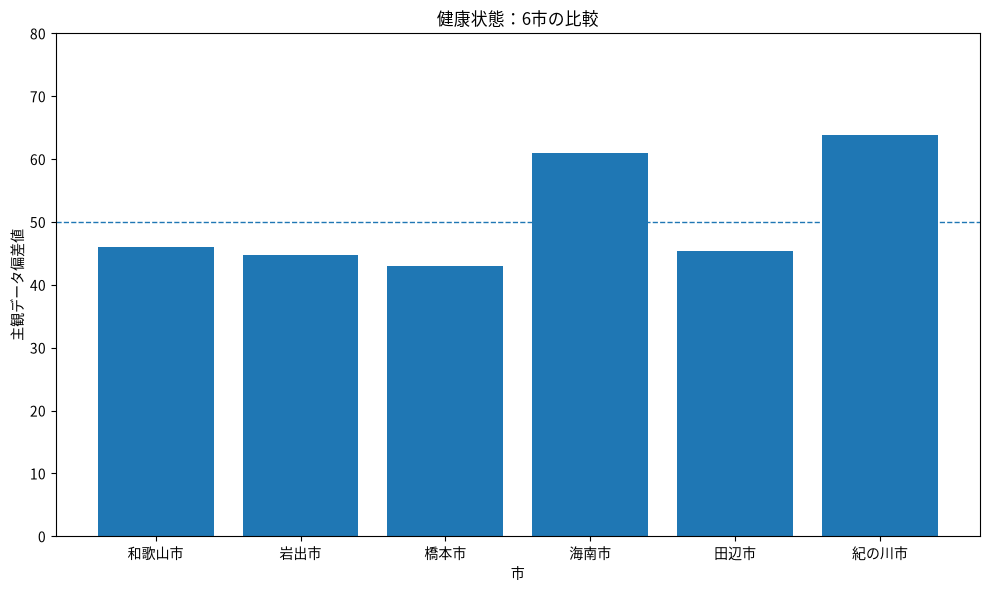

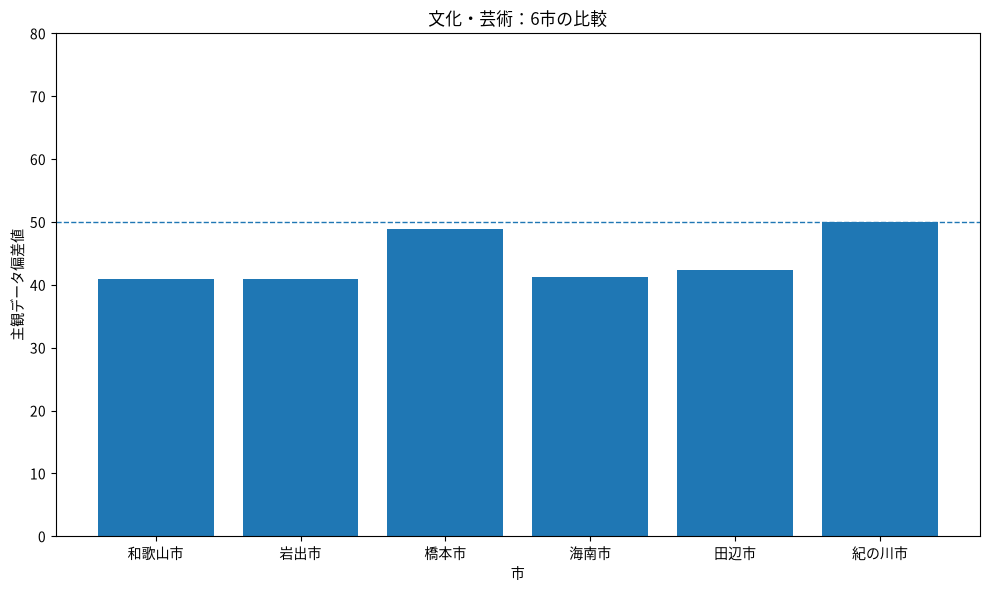

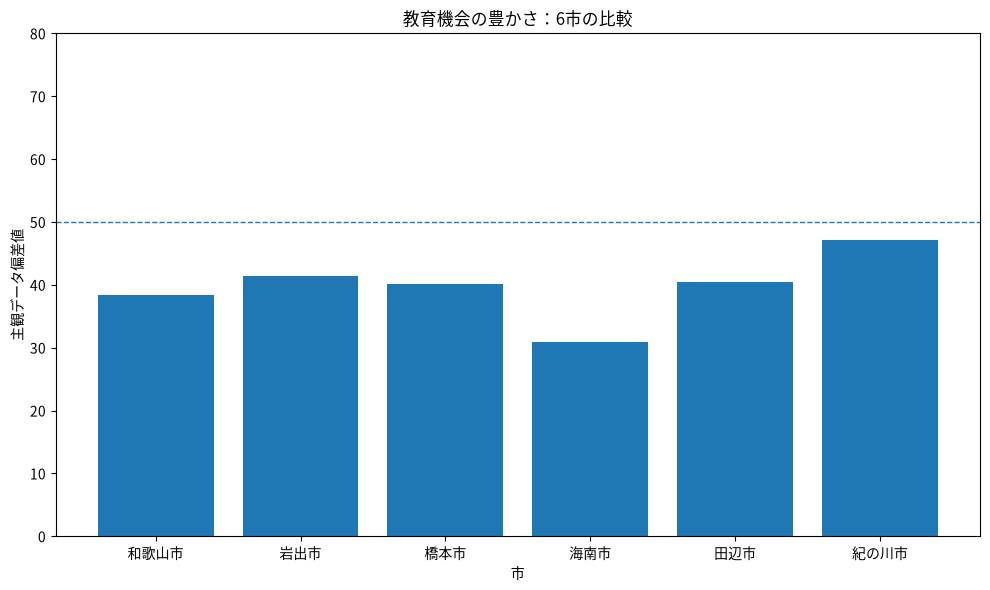

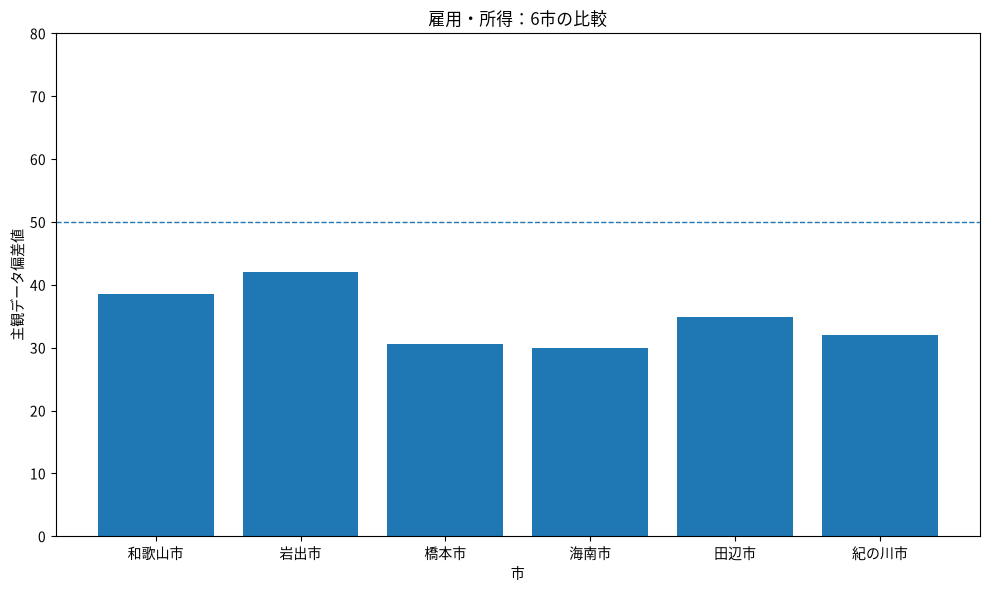

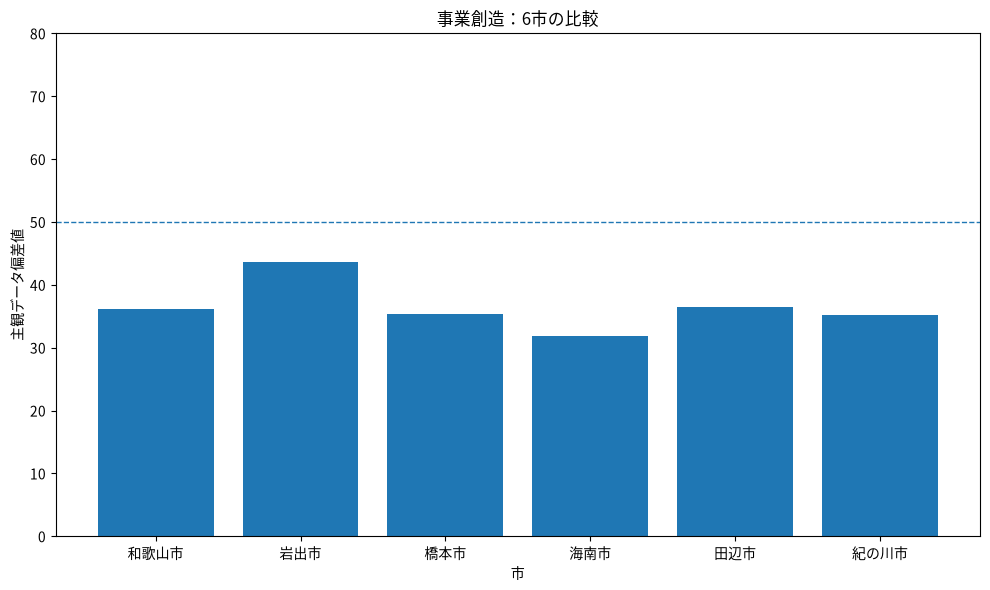

In [20]:
import matplotlib.pyplot as plt
from pathlib import Path

# 日本語フォント
plt.rcParams["font.family"] = "Noto Sans CJK JP"

# 保存先
OUTPUT_DIR = Path("../result/city_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# カテゴリ別データ
df_cat = dfs["カテゴリー別"].copy()

# 「和歌山県 」を削除して市名だけにする
df_cat["市"] = df_cat["地域"].str.replace("和歌山県 ", "", regex=False)

# 24施策
categories = df_cat["カテゴリ・評価指標"].unique()

# 市の順番を固定
city_order = [
    "和歌山市",
    "岩出市",
    "橋本市",
    "海南市",
    "田辺市",
    "紀の川市"
]

for category in categories:

    # 対象施策だけ抽出
    df_plot = df_cat[
        df_cat["カテゴリ・評価指標"] == category
    ].copy()

    # 市の順番を指定
    df_plot["市"] = pd.Categorical(
        df_plot["市"],
        categories=city_order,
        ordered=True
    )

    df_plot = df_plot.sort_values("市")

    # グラフ作成
    plt.figure(figsize=(10, 6))

    plt.bar(
        df_plot["市"],
        df_plot["主観データ偏差値"]
    )

    # 全国平均50を表示
    plt.axhline(
        50,
        linestyle="--",
        linewidth=1
    )

    plt.title(f"{category}：6市の比較")
    plt.ylabel("主観データ偏差値")
    plt.xlabel("市")

    plt.ylim(0, 80)

    plt.tight_layout()

    # ファイル名に使えない文字を除去
    safe_name = category.replace("/", "_").replace("\\", "_")

    plt.savefig(
        OUTPUT_DIR / f"{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

#クラスタリング

In [22]:
# ==========================================
# 6市 × 24カテゴリ：クラスタリング
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# ------------------------------------------
# 1. クラスタリング用データを作成
# ------------------------------------------

df_cat = dfs["カテゴリー別"].copy()

# 「和歌山県 和歌山市」→「和歌山市」
df_cat["市"] = df_cat["地域"].str.replace(
    "和歌山県 ", "", regex=False
)

# 市 × 24カテゴリ
city_subjective = df_cat.pivot_table(
    index="市",
    columns="カテゴリ・評価指標",
    values="主観データ偏差値"
)

print("クラスタリング対象データ")
display(city_subjective)

print("データサイズ:", city_subjective.shape)

クラスタリング対象データ


カテゴリ・評価指標,デジタル生活,事故・犯罪,事業創造,住宅環境,健康状態,公共空間,初等・中等教育,医療・福祉,地域とのつながり,地域行政,...,環境共生,移動・交通,自己効力感,自然の恵み,自然景観,自然災害,買物・飲食,遊び・娯楽,都市景観,雇用・所得
市,,,,,,,,,,,,,,,,,,,,,
和歌山市,37.1,43.4,36.2,53.5,46.0,46.2,45.2,51.2,44.7,41.4,...,35.6,43.0,48.8,49.4,51.8,38.8,48.9,44.0,46.4,38.5
岩出市,40.9,43.0,43.6,49.7,44.8,37.3,37.8,46.0,46.2,39.0,...,44.0,36.8,44.0,54.7,44.9,41.6,58.9,43.2,45.7,42.0
橋本市,44.9,44.8,35.4,59.3,43.0,44.0,23.3,31.4,51.1,40.4,...,47.8,39.8,42.3,63.7,59.3,51.3,35.9,34.6,42.5,30.6
海南市,36.3,34.6,31.9,53.1,60.9,34.0,30.3,35.0,57.3,41.9,...,35.0,34.6,57.9,54.3,42.7,44.5,22.0,33.4,37.3,30.0
田辺市,35.0,43.9,36.4,45.8,45.4,40.9,33.3,35.4,49.4,35.4,...,49.3,31.0,29.3,64.5,62.2,44.5,39.2,35.0,43.3,34.8
紀の川市,43.4,36.8,35.2,62.6,63.8,49.4,35.2,41.0,59.7,45.5,...,49.3,33.2,56.3,63.8,54.5,52.0,28.1,30.5,39.7,32.0


データサイズ: (6, 24)


In [23]:
# ------------------------------------------
# 2. 標準化
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(city_subjective)

X_scaled = pd.DataFrame(
    X_scaled,
    index=city_subjective.index,
    columns=city_subjective.columns
)

display(X_scaled)

カテゴリ・評価指標,デジタル生活,事故・犯罪,事業創造,住宅環境,健康状態,公共空間,初等・中等教育,医療・福祉,地域とのつながり,地域行政,...,環境共生,移動・交通,自己効力感,自然の恵み,自然景観,自然災害,買物・飲食,遊び・娯楽,都市景観,雇用・所得
市,,,,,,,,,,,,,,,,,,,,,
和歌山市,-0.674118,0.594316,-0.070921,-0.089125,-0.555838,0.810481,1.642912,1.632068,-1.224200,0.261908,...,-1.302630,1.633743,0.246967,-1.536125,-0.108678,-1.386746,0.816822,1.433201,1.228684,0.883580
岩出市,0.350541,0.491700,2.028352,-0.766473,-0.699280,-0.893443,0.539352,0.874322,-0.950125,-0.523816,...,0.082445,0.099015,-0.253924,-0.631518,-1.086781,-0.802853,1.628235,1.274325,1.009089,1.686835
橋本市,1.429130,0.953470,-0.297870,0.944723,-0.914442,0.389286,-1.623028,-1.253195,-0.054815,-0.065477,...,0.709027,0.841625,-0.431323,0.904607,0.954477,1.219920,-0.238014,-0.433601,0.005228,-0.929480
海南市,-0.889836,-1.663229,-1.290769,-0.160425,1.225233,-1.525235,-0.579120,-0.728602,1.078026,0.425601,...,-1.401564,-0.445566,1.196574,-0.699790,-1.398640,-0.198107,-1.365878,-0.671917,-1.626045,-1.067181
田辺市,-1.240377,0.722585,-0.014184,-1.461647,-0.627559,-0.204216,-0.131731,-0.670314,-0.365433,-1.702404,...,0.956362,-1.336699,-1.787904,1.041152,1.365564,-0.198107,0.029752,-0.354163,0.256194,0.034425
紀の川市,1.024660,-1.098843,-0.354607,1.532947,1.571885,1.423127,0.151615,0.145720,1.516546,1.604188,...,0.956362,-0.792118,1.029610,0.921675,0.274058,1.365893,-0.870916,-1.247845,-0.873150,-0.608178


In [24]:
# ------------------------------------------
# 3. クラスタ数を比較
# ------------------------------------------

silhouette_scores = {}

for k in range(2, 5):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores[k] = score

    print(f"k={k} : silhouette score = {score:.3f}")

k=2 : silhouette score = 0.160
k=3 : silhouette score = 0.153
k=4 : silhouette score = 0.114


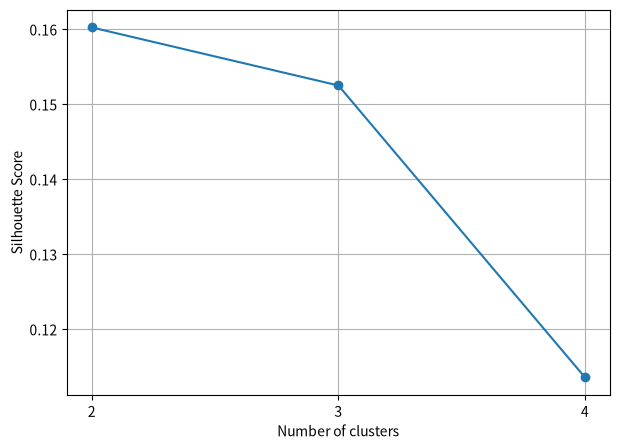

In [25]:
# ------------------------------------------
# 4. シルエット係数
# ------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.xticks([2, 3, 4])
plt.grid(True)

plt.show()

In [26]:
# ------------------------------------------
# 5. K-means
# ------------------------------------------

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_scaled)

cluster_result = pd.DataFrame({
    "市": city_subjective.index,
    "クラスタ": labels
})

display(
    cluster_result.sort_values("クラスタ")
)

,市,クラスタ
0,和歌山市,0
1,岩出市,0
4,田辺市,0
2,橋本市,1
5,紀の川市,1
3,海南市,2


In [30]:
# ------------------------------------------
# 幸福度データの市名を統一
# ------------------------------------------

mean_happiness_city = mean_happiness.copy()

mean_happiness_city["市"] = (
    mean_happiness_city["地域"]
    .str.replace("和歌山県 ", "", regex=False)
)

mean_happiness_city = mean_happiness_city[
    ["市", "平均幸福度スコア"]
]

display(mean_happiness_city)

,市,平均幸福度スコア
0,和歌山市,6.381
1,岩出市,6.344
2,橋本市,6.488
3,海南市,6.489
4,田辺市,6.144
5,紀の川市,6.924


In [31]:
# ------------------------------------------
# クラスタリング結果に幸福度を追加
# ------------------------------------------

cluster_result = cluster_result.merge(
    mean_happiness_city,
    on="市",
    how="left"
)

display(
    cluster_result.sort_values(
        ["クラスタ", "平均幸福度スコア"]
    )
)

,市,クラスタ,平均幸福度スコア
4,田辺市,0,6.144
1,岩出市,0,6.344
0,和歌山市,0,6.381
2,橋本市,1,6.488
5,紀の川市,1,6.924
3,海南市,2,6.489


In [32]:
# ------------------------------------------
# クラスタごとの幸福度
# ------------------------------------------

cluster_happiness = (
    cluster_result
    .groupby("クラスタ")["平均幸福度スコア"]
    .agg(["mean", "min", "max"])
    .reset_index()
    .rename(columns={
        "mean": "幸福度平均",
        "min": "幸福度最小",
        "max": "幸福度最大"
    })
)

display(cluster_happiness)

,クラスタ,幸福度平均,幸福度最小,幸福度最大
0,0,6.289667,6.144,6.381
1,1,6.706000,6.488,6.924
2,2,6.489000,6.489,6.489
